<a href="https://colab.research.google.com/github/HarikaDevi23/DATA_SCIENCE/blob/main/Harika_Devi_Alla_ICP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICP3: Sacramento Housing Data Analysis

Harika Devi Alla
Student Id: 16358867

1. Load the Sacramento real estate transactions dataset  
2. Inspect its shape and columns  
3. Compute summary statistics (mean, median) for house prices  
4. List and count property types  
5. Compute max and mean prices by property type  
6. Visualize the distributions and comparisons with plots  

In [3]:
# --- Cell 1: Imports and settings ---
import pandas as pd
import matplotlib.pyplot as plt


## 1. Load the dataset

We’ll pull the CSV directly from GitHub into a pandas DataFrame.


In [6]:
url = "https://raw.githubusercontent.com/JuliaData/CSV.jl/refs/heads/main/test/testfiles/Sacramentorealestatetransactions.csv"
df = pd.read_csv(url)
print("Loaded", len(df), "rows with", df.shape[1], "columns.")
df.head()


Loaded 985 rows with 12 columns.


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 2. Number of columns

Let’s confirm exactly how many columns there are.


In [16]:
num_columns = df.shape[1]
print(f"Number of columns in the DataFrame: {num_columns}")

num_rows = df.shape[0]
print(f"Number of rows in the DataFrame: {num_rows}")


Number of columns in the DataFrame: 12
Number of rows in the DataFrame: 985


## 3. Price summary: mean & median

Compute the mean and median of the `price` column.


In [8]:
mean_price = df['price'].mean()
median_price = df['price'].median()
print(f"Mean house price: ${mean_price:,.2f}")
print(f"Median house price: ${median_price:,.2f}")


Mean house price: $234,144.26
Median house price: $213,750.00


### 3.1 Price distribution

A histogram helps us see the spread and skew of house prices.


Text(0, 0.5, 'Frequency')

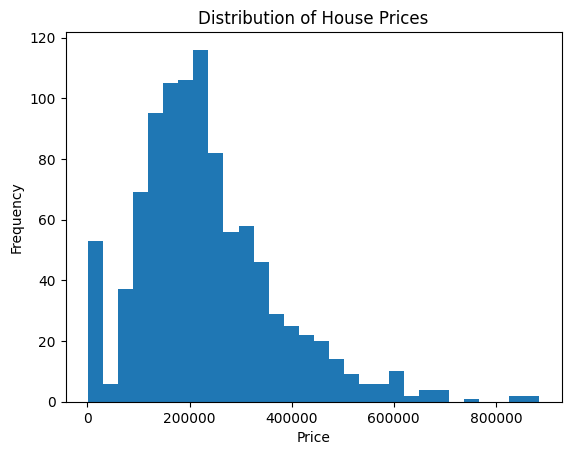

In [9]:
plt.figure()
plt.hist(df['price'], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")


## 4. Property types

What unique property categories are present?


In [10]:
property_types = df['type'].unique()
print("Property types:", property_types)


Property types: ['Residential' 'Condo' 'Multi-Family' 'Unkown']


## 5. Maximum condo price

Filter to “Condo” entries and find the highest sale price.


In [11]:
max_condo_price = df.loc[df['type'] == 'Condo', 'price'].max()
print(f"Maximum price for a Condo: ${max_condo_price:,.2f}")


Maximum price for a Condo: $360,000.00


## 6. Mean price by property type

Group by `type` and compute average price for each.


In [12]:
mean_by_type = df.groupby('type')['price'].mean().reset_index()
print(mean_by_type.to_string(index=False))


        type         price
       Condo 150082.185185
Multi-Family 224534.692308
 Residential 239186.162486
      Unkown 275000.000000


### 6.1 Mean price comparison plot

A bar chart makes it easier to compare average prices across types.


([0, 1, 2, 3],
 [Text(0, 0, 'Condo'),
  Text(1, 0, 'Multi-Family'),
  Text(2, 0, 'Residential'),
  Text(3, 0, 'Unkown')])

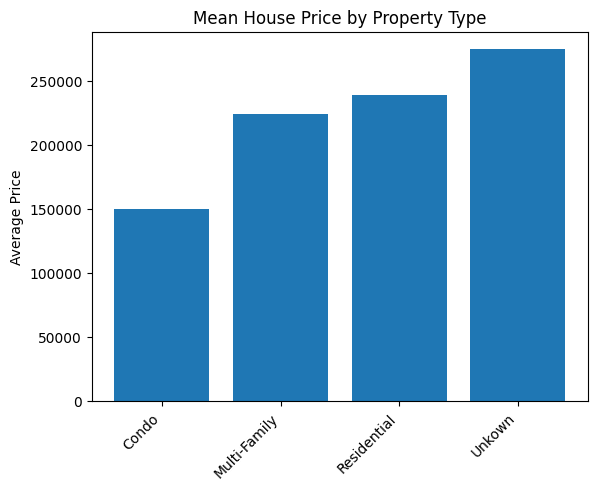

In [13]:
plt.figure()
plt.bar(mean_by_type['type'], mean_by_type['price'])
plt.title("Mean House Price by Property Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")


## 7. Count of each property type

How many listings of each type do we have?


In [14]:
count_by_type = df['type'].value_counts().reset_index()
count_by_type.columns = ['type', 'count']
print(count_by_type.to_string(index=False))


        type  count
 Residential    917
       Condo     54
Multi-Family     13
      Unkown      1


### 7.1 Property type counts plot

Visualize the frequency of each property type.


([0, 1, 2, 3],
 [Text(0, 0, 'Residential'),
  Text(1, 0, 'Condo'),
  Text(2, 0, 'Multi-Family'),
  Text(3, 0, 'Unkown')])

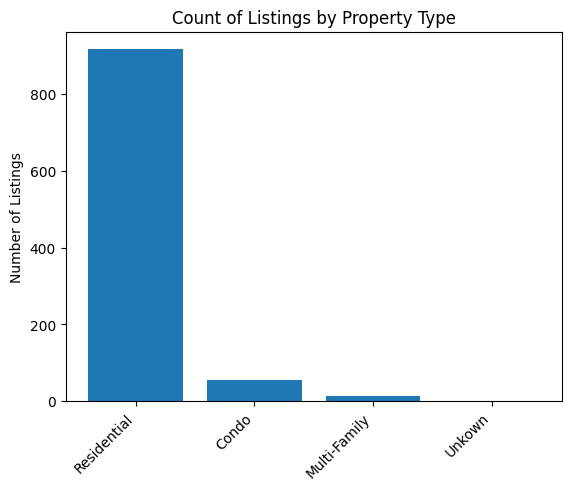

In [15]:
plt.figure()
plt.bar(count_by_type['type'], count_by_type['count'])
plt.title("Count of Listings by Property Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
